# LSTM Stock Price Prediction & Backtest

This project applies a **Long Short-Term Memory (LSTM)** model to predict the closing price of **Apple (AAPL)** stock.  

It is divided into two main parts:  
1. **Forecasting task** – Evaluate the predictive performance of an LSTM on financial time series, using MSE as the evaluation metric and visualizing predicted vs. actual prices.  
2. **Trading strategy simulation** – Test a rule-based trading strategy driven by the LSTM predictions, with a backtest including **risk management** (Stop Loss, Take Profit, and Kelly criterion).  

---

###Educational Goals
This project illustrates the intersection between **machine learning** and **quantitative finance**:
- ML models such as LSTMs can capture **non-linear temporal dependencies** in financial data.  
- A backtest framework demonstrates how **raw model outputs** can be translated into **practical trading decisions**.  
- It highlights both the **potential** and the **limitations** of applying deep learning to financial markets.  

In [ ]:
# imports

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler


In [ ]:
# CUDA should be used if compatible with the hardware
device = torch.device('cpu')

## 1. Downloading and Normalizing the Data

We use **`yfinance`** to fetch the historical daily prices of AAPL starting from 2020.  

The year **2020** was chosen as a starting point because it provides:
- A sufficiently large dataset to train the model,  
- While still limiting the risk of overfitting to outdated patterns.  

For the train/test split, we allocate **80% of the data for training** and **20% for testing** in this demonstration.  

Next, we apply the **`MinMaxScaler`** from Scikit-Learn to normalize the closing prices between 0 and 1.  
This normalization helps stabilize the LSTM training process and ensures that the model can better capture relative changes.  

In other words, we transform the raw price series into a normalized **time series** that can be directly used as input for sequence prediction.  


In [ ]:
ticker = 'AAPL'
df= yf.download(ticker, '2020-01-01')

/tmp/ipython-input-255586931.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df= yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400
2020-01-03,71.833290,72.594055,71.608685,71.765667,146322800
2020-01-06,72.405685,72.444328,70.703020,70.954195,118387200
2020-01-07,72.065147,72.671341,71.845369,72.415337,108872000
2020-01-08,73.224403,73.526295,71.768079,71.768079,132079200
...,...,...,...,...,...
2025-09-22,256.079987,256.640015,248.119995,248.300003,105517400
2025-09-23,254.429993,257.339996,253.580002,255.880005,60275200


<Axes: xlabel='Date'>

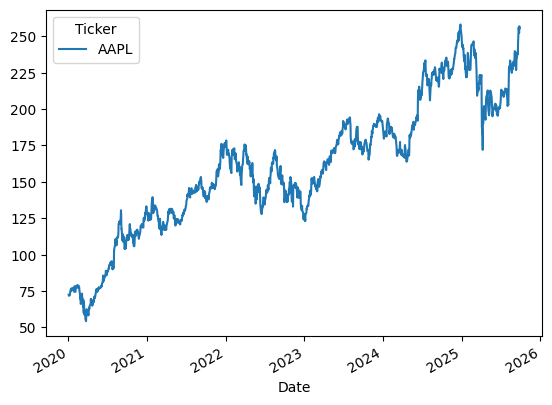

In [ ]:
df.Close.plot()

In [ ]:
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [ ]:
df.Close

Ticker,AAPL
Date,
2020-01-02,0.089415
2020-01-03,0.085954
2020-01-06,0.088763
2020-01-07,0.087092
2020-01-08,0.092781
...,...
2025-09-22,0.990069
2025-09-23,0.981973
2025-09-24,0.971570


## 2. Sequence building
- Each sequence correspond in a **30 consecutive days** window
- The model learn to predict **day 31** from the 30 days
- Datas are split between **train (80%)** and **test (20%)**

In [ ]:
seq_lenght = 30
data = []

for i in range(len(df) - seq_lenght):
  data.append(df.Close[i:i+seq_lenght])

data = np.array(data)

In [ ]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

## 3. LSTM Model

We implement a **simple yet effective architecture**:  
- 2 stacked LSTM layers with 32 hidden units,  
- Followed by a fully connected layer that outputs the next predicted price.  

> **Why LSTM?**  
LSTMs (Long Short-Term Memory networks) are specifically designed for sequential data.  
They can capture **long-term dependencies** in time series and mitigate the vanishing gradient problem found in standard RNNs.  
This makes them particularly well-suited for financial time series, where past values influence future trends.  


In [ ]:
class PredictionModel(nn.Module):

  def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
    super(PredictionModel, self).__init__()
    self.num_layers = num_layers
    self.hidden_dim = hidden_dim

    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

    out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
    out = self.fc(out[:, -1, :])

    return out

In [ ]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

## 4. Model Training

The model is trained with the following configuration:  
- Optimizer: **Adam**  
- Loss function: **MSE (Mean Squared Error)**  
- Number of epochs: **200**  

During training, we can observe the convergence of the loss over time, indicating that the model is learning to minimize prediction errors.  


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
num_epochs = 200
losses = []


for i in range(num_epochs):
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)

    losses.append(loss.item())  # sauvegarde de la loss

    if i % 25 == 0:
        print(f"Epoch {i}, Loss: {loss.item():.5f}")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0, Loss: 0.12601
Epoch 25, Loss: 0.00513
Epoch 50, Loss: 0.00108
Epoch 75, Loss: 0.00072
Epoch 100, Loss: 0.00055
Epoch 125, Loss: 0.00050
Epoch 150, Loss: 0.00047
Epoch 175, Loss: 0.00044


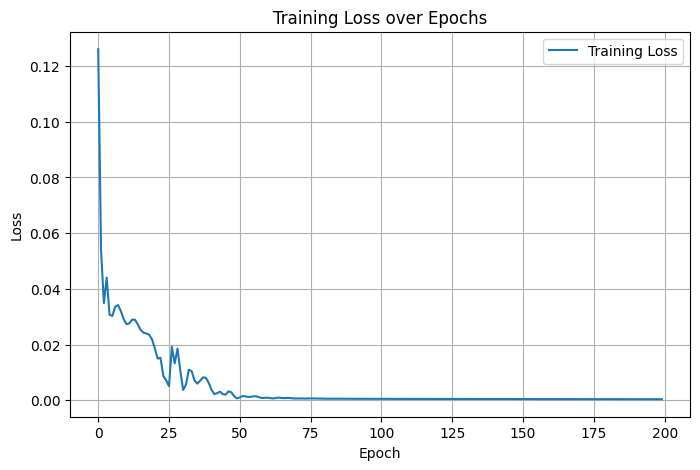

In [ ]:
plt.figure(figsize=(8,5))
# si tu as une variable 'loss' tensor
plt.plot([l.detach().numpy() if isinstance(l, torch.Tensor) else l for l in losses], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.eval()

y_test_pred = model(X_test)

y_train_pred= scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred= scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test= scaler.inverse_transform(y_test.detach().cpu().numpy())

In [ ]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

## 5. Results and Prediction Errors

The model manages to approximate the test prices, although residual errors remain due to the inherent noise of financial markets.  

Performance is evaluated using the **RMSE (Root Mean Squared Error)**:  
- Training RMSE  
- Testing RMSE  

We also plot the actual vs. predicted prices, with visual markers indicating **"Memory Resets"**, which are caused by the chosen sequence length.  


In [ ]:
train_rmse

4.167489051818848

In [ ]:
test_rmse

7.467984199523926

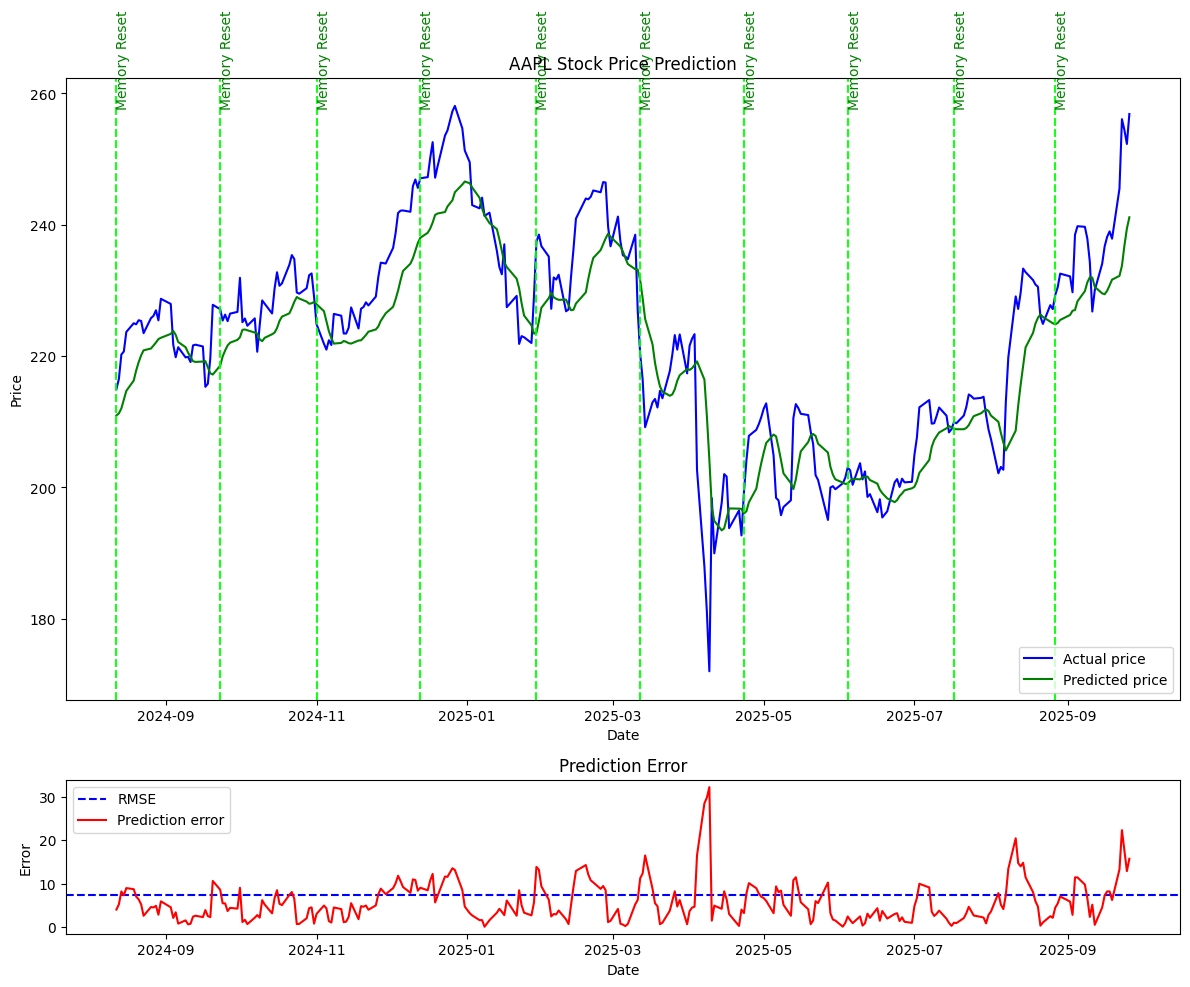

In [ ]:
fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(4, 1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted price')

for i in range(0, len(y_test), 29):
    ax1.axvline(df.iloc[-len(y_test):].index[i], color='lime', linestyle='--', alpha=0.7)

ax1.legend()
ax1.set_title(f"{ticker} Stock Price Prediction")
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction error')


for i in range(0, len(y_test), 29):
    ax1.axvline(df.iloc[-len(y_test):].index[i], color='lime', linestyle='--', alpha=0.7)
    ax1.text(df.iloc[-len(y_test):].index[i], max(y_test), 'Memory Reset', rotation=90, color='green')


ax2.legend()
ax2.set_title('Prediction Error')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')

plt.tight_layout()
plt.show()


## 6. Trading Strategy Backtest

The goal is not only to predict, but also to **test an actionable trading strategy**:  
- Enter long/short positions based on the predictive signal,  
- Apply risk management with a Stop-Loss (2%) and Take-Profit (3%),  
- Allocate capital using the **Kelly criterion**.  

A portfolio is then simulated over the test period and compared against a random strategy baseline.  


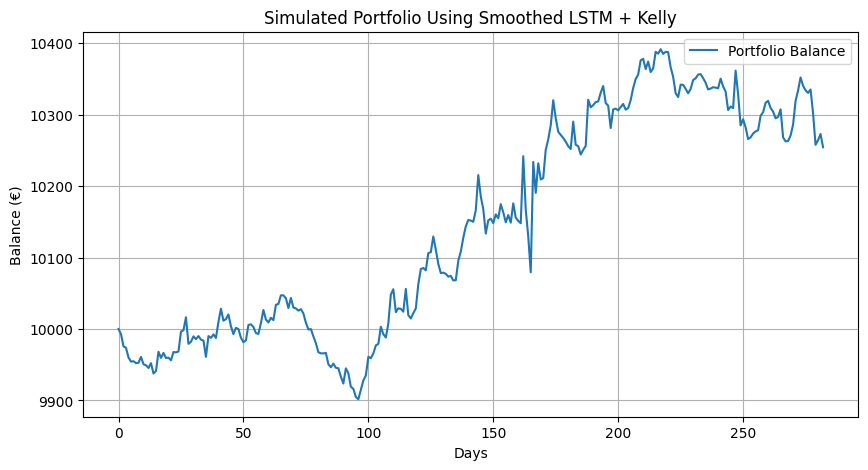

In [ ]:
"""
More complete backtest strategy,more conservative, work in progress
"""
# --- Params ---
initial_balance = 10000
max_fraction = 0.1    # % max of total capital per trade
stop_loss = 0.02      # 2% Stop loss
take_profit = 0.03    # 3%
threshold = 0.001     # minmium delta for signal




# --- Signal ---
y_pred_smooth = pd.Series(y_test_pred.flatten()).ewm(span=3).mean().values
signal = np.where((y_pred_smooth - y_test.flatten()) > threshold, 1,
                  np.where((y_pred_smooth - y_test.flatten()) < -threshold, -1, 0))

# --- Align lenghts for daily returns ---
daily_returns = np.diff(y_test.flatten()) / y_test[:-1].flatten()
signal = signal[:-1]

# --- derivating probabilty for Kelly criterion from noemalized MSE ---

mse = np.mean((y_test_pred.flatten() - y_test.flatten())**2)
sigma_price2 = np.var(y_test.flatten())

# probability estimation from mse
p_est = 1 / (1 + mse / sigma_price2)
p_est = np.clip(p_est, 0.01, 0.99)  # avoid 0 or 1


# --- Backtest ---
balance = initial_balance
balances = [balance]
position = 0  # 1 = long, -1 = short, 0 = cash

for i in range(len(daily_returns)):
    # change position if signal !=
    if signal[i] != 0 and signal[i] != position:
        position = signal[i]

    # Kelly
    b = 1  # odds 1:1 for spot trading
    f = (p_est * b - (1 - p_est)) / b
    f = np.clip(f, 0, max_fraction)

    # PnL compute
    pnl = f * daily_returns[i] * position

    # apply TP / SL
    pnl = np.clip(pnl, -stop_loss, take_profit)

    # balance update
    balance += balance * pnl
    balances.append(balance)

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(balances, label='Portfolio Balance')
plt.title('Simulated Portfolio Using Smoothed LSTM + Kelly')
plt.xlabel('Days')
plt.ylabel('Balance (€)')
plt.grid(True)
plt.legend()
plt.show()


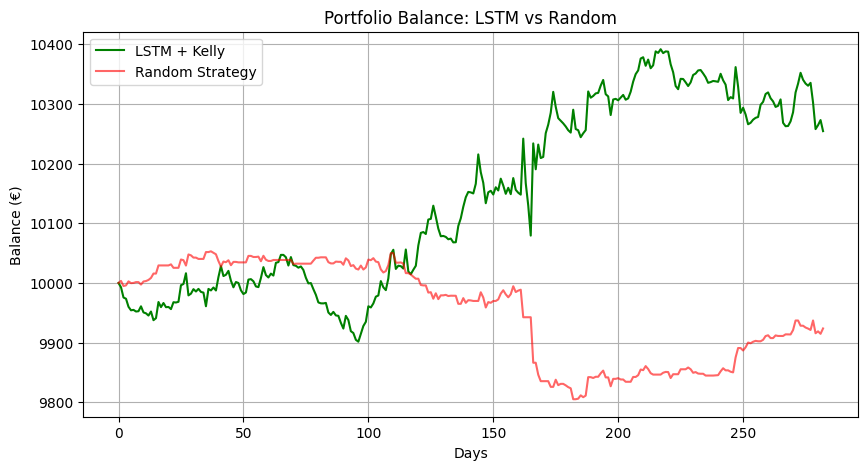

In [ ]:
# --- Baseline random backtest ---
np.random.seed(42)
random_signals = np.random.choice([-1, 0, 1], size=len(daily_returns))

balance_rand = initial_balance
balances_rand = [balance_rand]

for i in range(len(daily_returns)):
    position = random_signals[i]

    f = 0.05
    pnl = f * daily_returns[i] * position
    pnl = np.clip(pnl, -stop_loss, take_profit)
    balance_rand += balance_rand * pnl
    balances_rand.append(balance_rand)

# --- comparative plotting ---
plt.figure(figsize=(10,5))
plt.plot(balances, label='LSTM + Kelly', color='green')
plt.plot(balances_rand, label='Random Strategy', color='red', alpha=0.6)
plt.title('Portfolio Balance: LSTM vs Random')
plt.xlabel('Days')
plt.ylabel('Balance (€)')
plt.grid(True)
plt.legend()
plt.show()


**Conclusion:**

The LSTM-based trading strategy clearly outperforms a random baseline, demonstrating a real edge in predicting short-term price movements. The model is able to generate positive PnL over the test period, showing that it captures some meaningful patterns in the data.

However, there are clear limitations:

The strategy **does not outperform** a simple buy-and-hold on the S&P 500, highlighting the challenges of intraday trading with a machine learning model.

Using only the closing price as a feature limits predictive power. Incorporating additional features (volume, technical indicators, news sentiment) could improve performance.

Short horizons and market noise constrain the model’s ability to generalize.

Overall, the project demonstrates the practical application of LSTM networks to financial time series while maintaining a critical perspective on the limitations of ML in real-world trading.